# 1) Experiment Overview

This notebook implements the experimental pipeline used to compare tree-based machine learning algorithms under different dataset characteristics.

**The experiments analyze the impact of:**

- dataset size
- class imbalance
- class type (binary vs. multi-class)

**The following algorithms are evaluated:**

- Decision Tree (CART)
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

**The pipeline performs the following steps:**

1. dataset loading and preprocessing  
2. dataset size and class imbalance generation  
3. hyperparameter optimization  
4. model training and evaluation  
5. statistical significance testing  
6. result aggregation and visualization


## 2) Project Structure and Execution

This notebook runs the experimental pipeline for the study and interacts with the GitHub project repository that stores datasets and previously generated experiment artifacts.

When executed in Google Colab, the repository is cloned so that the notebook can access the required datasets and configuration files.

**The repository contains:**

- `datasets/original_datasets`  
  Original datasets used in the experiments.

- `config`  
  Tuned hyperparameters stored as JSON files.  
  These files are loaded by the notebook to avoid repeating the expensive hyperparameter tuning stage.

- `results`  
  Experimental results generated by the notebook and uploaded manually to the repository.

- `results/figures`  
  Visualizations produced from experiment results.

During execution, the notebook generates intermediate datasets, results, and figures in the Colab runtime environment. These files are automatically downloaded and then uploaded manually to the GitHub repository.

The following code cell prepares the repository environment and defines paths used to load datasets and configuration files.

In [1]:
# ==================================================
# Repository Setup
# ==================================================
# Clone the GitHub repository when running in Colab

import os

REPO_NAME = "Tree-algorithms-dataset-characteristics"
REPO_URL = "https://github.com/Ilaha-Habibova/Tree-algorithms-dataset-characteristics.git"

if "COLAB_GPU" in os.environ and not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

if "COLAB_GPU" in os.environ and os.path.exists(REPO_NAME):
    %cd {REPO_NAME}


# ==================================================
# Paths used in the notebook
# ==================================================

BASE_PATH = os.getcwd()

# Dataset location
ORIGINAL_DATASETS_PATH = os.path.join(
    BASE_PATH, "datasets", "original_datasets"
)

# Hyperparameter configuration files
CONFIG_PATH = os.path.join(
    BASE_PATH, "config"
)

print("Repository ready.")


/content/Tree-algorithms-dataset-characteristics
Repository ready.


## 3) Environment Setup and Library Versions

This section installs the required libraries and imports all packages used throughout the experimental pipeline.

The libraries support:

- data manipulation and numerical computation
- implementation of machine learning algorithms
- statistical significance testing
- visualization of experimental results

For reproducibility, the versions of the main libraries used in the experiment are also recorded.

In [2]:
# ==================================================
# Install required libraries (for Colab environment)
# ==================================================
!pip install -q catboost scikit-posthocs  itables


# ==================================================
# Core libraries
# ==================================================
import pandas as pd
import numpy as np
import random
import time


# ==================================================
# Visualization
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns


# ==================================================
# Statistical testing
# ==================================================
from scipy import stats
import scikit_posthocs as sp


# ==================================================
# Scikit-learn utilities
# ==================================================
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline


# ==================================================
# Tree-based machine learning algorithms
# ==================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb


# ==================================================
# Library versions (reproducibility)
# ==================================================
import sklearn
import scipy
import matplotlib
import scikit_posthocs

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)
print("catboost:", cb.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-posthocs:", scikit_posthocs.__version__)

numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.10
scipy: 1.16.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-posthocs: 0.12.0


## 4) Random Seed Configuration

A global random seed is defined to ensure reproducibility of the experimental results.

Randomness may occur during dataset sampling, cross-validation splitting, and model training.  
Setting a fixed seed ensures that the same results are obtained across repeated runs of the notebook.

The seed value used in this study is:

`SEED = 42`


In [3]:
# ==================================================
# Random Seed Configuration
# ==================================================

SEED = 42

random.seed(SEED)      # Python random generator
np.random.seed(SEED)   # NumPy random generator

print("Random seed set to:", SEED)

Random seed set to: 42


## 5) Dataset Loading and Inspection

This section loads the original datasets used in the experiments and performs a basic inspection of their structure.

The datasets are stored in the repository directory:

`datasets/original_datasets`

Two datasets are used:

- **Online Shoppers Purchasing Intention Dataset** – a binary classification dataset containing user session information from an e-commerce website.
- **Dry Bean Dataset** – a multi-class classification dataset containing morphological measurements of seven bean varieties.

After loading the datasets, a brief inspection is performed to verify:

- dataset dimensions
- feature data types
- missing values
- class distributions


In [4]:
# ==================================================
# Dataset Loading
# ==================================================

# File paths
shoppers_path = os.path.join(
    ORIGINAL_DATASETS_PATH,
    "online_shoppers_intention.csv"
)

beans_path = os.path.join(
    ORIGINAL_DATASETS_PATH,
    "Dry_Bean_Dataset.csv"
)

# Load datasets
shoppers = pd.read_csv(shoppers_path)
beans = pd.read_csv(beans_path)

# Display first rows to verify loading
print("Online Shoppers dataset preview:")
display(shoppers.head())

print("\nDry Bean dataset preview:")
display(beans.head())

# ==================================================
# Dataset Inspection
# ==================================================

def inspect_dataset(df, target, name):

    print("\n====================================")
    print(f"{name.upper()} DATASET")
    print("====================================")

    print("\nShape:", df.shape)

    print("\nFeature types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())

    print(f"\nTarget distribution ({target}):")
    print(df[target].value_counts())

    print("\nClass proportions:")
    print(df[target].value_counts(normalize=True))

# Inspect both datasets
inspect_dataset(shoppers, "Revenue", "Online Shoppers")
inspect_dataset(beans, "Class", "Dry Bean")

Online Shoppers dataset preview:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Dry Bean dataset preview:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



ONLINE SHOPPERS DATASET

Shape: (12330, 18)

Feature types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay       

## 6) Feature and Target Definition

In this section, the predictor variables (**X**) and the target variable (**y**) are defined for both datasets.

For the **Online Shoppers dataset**, the target variable is `Revenue`, which indicates whether a session resulted in a purchase. The variables `Weekend` and `Revenue` are originally stored as boolean values and are converted to integers (`0` / `1`) for consistent numerical representation.

For the **Dry Bean dataset**, the target variable `Class` contains textual labels representing bean varieties. These labels are converted into integer values using **LabelEncoder** so that the algorithms can perform multi-class classification.

After defining the feature matrices and target variables, the feature types are identified. Categorical variables are detected based on their data types (`object` or `category`) and will later be transformed using **one-hot encoding**, while numerical variables are passed directly to the models.


In [5]:
# ==================================================
# Feature and Target Definition
# ==================================================

# --------------------------------------------------
# Online Shoppers dataset
# --------------------------------------------------

# Convert boolean columns to integers
shoppers["Weekend"] = shoppers["Weekend"].astype(int)
shoppers["Revenue"] = shoppers["Revenue"].astype(int)

# Define features and target
X_shoppers = shoppers.drop(columns=["Revenue"])
y_shoppers = shoppers["Revenue"]


# --------------------------------------------------
# Dry Bean dataset
# --------------------------------------------------

# Encode class labels as integers
bean_label_encoder = LabelEncoder()

y_beans_encoded = bean_label_encoder.fit_transform(beans["Class"])

y_beans = pd.Series(
    y_beans_encoded,
    name="Class"
)

# Define feature matrix
X_beans = beans.drop(columns=["Class"])


# --------------------------------------------------
# Save and display label encoding mapping
# --------------------------------------------------

bean_label_mapping = dict(
    zip(
        bean_label_encoder.classes_,
        bean_label_encoder.transform(bean_label_encoder.classes_)
    )
)


print("\nDry Bean Label Encoding Mapping:")
for k, v in bean_label_mapping.items():
    print(f"{k} → {v}")


# --------------------------------------------------
# Feature type identification
# --------------------------------------------------

# Online Shoppers dataset
categorical_features_shoppers = X_shoppers.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features_shoppers = X_shoppers.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

# Dry Bean dataset (all numerical)
categorical_features_beans = []
numerical_features_beans = X_beans.columns.tolist()


# --------------------------------------------------
# Verification
# --------------------------------------------------
print("\nOnline Shoppers feature matrix:", X_shoppers.shape)
print("Online Shoppers target:", y_shoppers.shape)

print("\nDry Bean feature matrix:", X_beans.shape)
print("Dry Bean target:", y_beans.shape)

print("\nOnline Shoppers categorical features:", categorical_features_shoppers)
print("Online Shoppers numerical features:", numerical_features_shoppers)

print("\nDry Bean numerical features:", numerical_features_beans)


Dry Bean Label Encoding Mapping:
BARBUNYA → 0
BOMBAY → 1
CALI → 2
DERMASON → 3
HOROZ → 4
SEKER → 5
SIRA → 6

Online Shoppers feature matrix: (12330, 17)
Online Shoppers target: (12330,)

Dry Bean feature matrix: (13611, 16)
Dry Bean target: (13611,)

Online Shoppers categorical features: ['Month', 'VisitorType']
Online Shoppers numerical features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']

Dry Bean numerical features: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


## 7) Preprocessing Pipeline

Before training the models, input features must be transformed into a format suitable for machine learning algorithms.

The **Online Shoppers dataset** contains categorical variables that are converted to numerical representations using **one-hot encoding**. Numerical variables are passed directly to the model.

The **Dry Bean dataset** contains only numerical features, so no encoding is required.

Preprocessing is implemented using **scikit-learn’s ColumnTransformer**, which allows different transformations to be applied to different feature groups. Integrating preprocessing into a **pipeline** ensures that transformations are applied consistently during cross-validation and prevents data leakage.


In [6]:
# ==================================================
# Preprocessing Pipeline
# ==================================================

# --------------------------------------------------
# Online Shoppers dataset
# --------------------------------------------------
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor_shoppers = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features_shoppers),
        ("num", "passthrough", numerical_features_shoppers)
    ]
)

print("Online Shoppers preprocessing defined.")

# --------------------------------------------------
# Dry Bean dataset
# --------------------------------------------------
# All features are numerical, so they are passed directly
# to the model without transformation.

preprocessor_beans = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_beans)
    ]
)

print("Dry Bean preprocessing defined.")

Online Shoppers preprocessing defined.
Dry Bean preprocessing defined.


## 8) Model Definitions

This section initializes the machine learning algorithms evaluated in the experiments.

At this stage, only **model objects are created**. No training is performed yet. The models will later be combined with the preprocessing pipeline and used during hyperparameter optimization and evaluation.

All models are stored in a **dictionary**, where the key represents the algorithm name and the value is the corresponding model object. This structure allows the experiment to iterate automatically over all algorithms.

Using a unified structure ensures that every model is trained and evaluated under identical experimental conditions.


In [7]:
# ==================================================
# Model Definitions
# ==================================================

models = {

    # Decision Tree (CART)
    "DecisionTree": DecisionTreeClassifier(
        random_state=SEED
    ),

    # Random Forest
    "RandomForest": RandomForestClassifier(
        random_state=SEED,
        n_jobs=1
    ),

    # Extra Trees
    "ExtraTrees": ExtraTreesClassifier(
        random_state=SEED,
        n_jobs=1
    ),

    # Gradient Boosting
    "GradientBoosting": GradientBoostingClassifier(
        random_state=SEED
    ),

    # XGBoost
    "XGBoost": xgb.XGBClassifier(
        random_state=SEED,
        n_jobs=1,
        verbosity=0,
        use_label_encoder=False
    ),

    # LightGBM
    "LightGBM": lgb.LGBMClassifier(
        random_state=SEED,
        n_jobs=1,
        verbosity=-1
    ),

    # CatBoost
    "CatBoost": cb.CatBoostClassifier(
        random_state=SEED,
        verbose=0,
        thread_count=1
    )
}

print("Models initialized:", list(models.keys()))

Models initialized: ['DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


## 9) Hyperparameter Optimization
Hyperparameters are optimized using **Randomized Search with stratified five-fold cross-validation.**
The tuning procedure is performed once for each original dataset. If previously tuned hyperparameters are already available in the repository (stored as configuration files), they are loaded directly in order to avoid repeating the computationally expensive tuning process.

**Balanced Accuracy** is used as the optimization metric because it assigns equal importance to all classes and is therefore consistent with the primary evaluation metric of this study.


In [8]:
# ==================================================
# Hyperparameter Optimization
# ==================================================

import json
import warnings
warnings.filterwarnings("ignore")

# --------------------------------------------------
# Cross-validation configuration
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# --------------------------------------------------
# Hyperparameter search spaces
# --------------------------------------------------

param_distributions = {

    "DecisionTree": {
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20, 30],
        "model__max_features": ["sqrt", "log2"],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "ExtraTrees": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20, 30],
        "model__max_features": ["sqrt", "log2"],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "GradientBoosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__max_depth": [3, 5, 7],
        "model__max_features": ["sqrt", "log2"],
        "model__min_samples_split": [2, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__max_depth": [3, 5, 7]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 50, 70],
        "model__feature_fraction": [0.8, 1.0]
    },

    "CatBoost": {
        "model__iterations": [200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__depth": [4, 6, 8],
        "model__l2_leaf_reg": [1, 3, 5]
    }
}


# --------------------------------------------------
# Generic tuning function
# --------------------------------------------------

def tune_models(X, y, preprocessor):

    best_params = {}

    for model_name, model in models.items():

        print(f"Tuning {model_name}...")

        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", model)
        ])

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions[model_name],
            n_iter=10,
            cv=cv,
            scoring="balanced_accuracy",
            n_jobs=1,
            random_state=SEED,
            verbose=0
        )

        search.fit(X, y)

        best_params[model_name] = {
            "best_params": search.best_params_,
            "best_score": search.best_score_
        }

        print("Best score:", round(search.best_score_, 4))

    return best_params

# --------------------------------------------------
# Load parameters if they exist
# --------------------------------------------------

beans_params_path = os.path.join(CONFIG_PATH, "best_params_beans.json")
shoppers_params_path = os.path.join(CONFIG_PATH, "best_params_shoppers.json")

if os.path.exists(beans_params_path) and os.path.exists(shoppers_params_path):

    print("Loading tuned hyperparameters from config...")

    with open(beans_params_path) as f:
        best_params_beans = json.load(f)

    with open(shoppers_params_path) as f:
        best_params_shoppers = json.load(f)

else:

    print("Hyperparameters not found. Running tuning...")

    best_params_shoppers = tune_models(
        X_shoppers,
        y_shoppers,
        preprocessor_shoppers
    )

    best_params_beans = tune_models(
        X_beans,
        y_beans,
        preprocessor_beans
    )

    # Save results
    with open(shoppers_params_path, "w") as f:
        json.dump(best_params_shoppers, f, indent=4)

    with open(beans_params_path, "w") as f:
        json.dump(best_params_beans, f, indent=4)

    print("Hyperparameters saved.")

    # --------------------------------------------------
    # Download files (for manual upload to GitHub)
    # --------------------------------------------------

    try:
        from google.colab import files

        files.download(shoppers_params_path)
        files.download(beans_params_path)

        print("JSON files downloaded. Upload them to the GitHub config folder.")

    except:
        print("Automatic download skipped (not running in Colab).")

print("\nHyperparameters ready.")

Loading tuned hyperparameters from config...

Hyperparameters ready.


## 10) Dataset Size Experiment

This experiment evaluates how classifier performance changes as dataset size increases.

Three dataset sizes are considered:

- Small: 1,000 observations
- Medium: 3,000 observations
- Large: 9,000 observations

Dataset subsets are generated using **stratified nested sampling** to preserve class distribution.

To **improve computational efficiency and reproducibility:**

- Dataset subsets are stored as CSV files.
- If the CSV files already exist, they are loaded instead of regenerated.

Model evaluation is performed using **stratified 5-fold cross-validation** with previously optimized hyperparameters.


In [9]:
# ==================================================
# Dataset Size Subsets (cached generation)
# ==================================================

from sklearn.model_selection import StratifiedShuffleSplit
import os
import shutil

# --------------------------------------------------
# Dataset size levels
# --------------------------------------------------

size_levels = [1000, 3000, 9000]

# --------------------------------------------------
# Define dataset subset storage path
# --------------------------------------------------

SIZE_DATASETS_PATH = os.path.join(
    BASE_PATH,
    "datasets",
    "generated_datasets",
    "size_experiments"
)

# Ensure directory exists
os.makedirs(SIZE_DATASETS_PATH, exist_ok=True)

# --------------------------------------------------
# Paths for generated dataset files
# --------------------------------------------------

shoppers_files = {
    size: os.path.join(
        SIZE_DATASETS_PATH,
        f"shoppers_size_{size}.csv"
    )
    for size in size_levels
}

beans_files = {
    size: os.path.join(
        SIZE_DATASETS_PATH,
        f"beans_size_{size}.csv"
    )
    for size in size_levels
}

# --------------------------------------------------
# Nested stratified subset generation
# --------------------------------------------------

def create_nested_subsets(X, y, sizes, seed=42):

    X = pd.DataFrame(X)
    y = pd.Series(y)

    subsets = {}
    selected = np.array([], dtype=int)

    for size in sizes:

        if len(selected) == 0:

            splitter = StratifiedShuffleSplit(
                n_splits=1,
                train_size=size,
                random_state=seed
            )

            idx, _ = next(splitter.split(X, y))
            selected = idx

        else:

            remaining = np.setdiff1d(np.arange(len(X)), selected)

            X_rem = X.iloc[remaining]
            y_rem = y.iloc[remaining]

            needed = size - len(selected)

            splitter = StratifiedShuffleSplit(
                n_splits=1,
                train_size=needed,
                random_state=seed
            )

            add_idx, _ = next(splitter.split(X_rem, y_rem))
            add_idx = remaining[add_idx]

            selected = np.concatenate([selected, add_idx])

        subsets[size] = (
            X.iloc[selected].copy(),
            y.iloc[selected].copy()
        )

    return subsets


# --------------------------------------------------
# Check whether subset files exist
# --------------------------------------------------

files_exist = all(
    os.path.exists(f)
    for f in list(shoppers_files.values()) + list(beans_files.values())
)

# --------------------------------------------------
# Load existing subsets
# --------------------------------------------------

if files_exist:

    print("Dataset size subsets found locally. Loading...")

    shoppers_size_subsets = {}
    beans_size_subsets = {}

    for size in size_levels:

        df = pd.read_csv(shoppers_files[size])

        shoppers_size_subsets[size] = (
            df.drop(columns=["Revenue"]),
            df["Revenue"]
        )

        df = pd.read_csv(beans_files[size])

        beans_size_subsets[size] = (
            df.drop(columns=["Class"]),
            df["Class"]
        )

# --------------------------------------------------
# Generate subsets if missing
# --------------------------------------------------

else:

    print("Dataset size subsets not found. Generating them...")

    shoppers_size_subsets = create_nested_subsets(
        X_shoppers,
        y_shoppers,
        size_levels,
        SEED
    )

    beans_size_subsets = create_nested_subsets(
        X_beans,
        y_beans,
        size_levels,
        SEED
    )

    # Save subsets
    for size in size_levels:

        Xs, ys = shoppers_size_subsets[size]
        df = pd.concat([Xs, ys], axis=1)
        df.to_csv(shoppers_files[size], index=False)

        Xb, yb = beans_size_subsets[size]
        df = pd.concat([Xb, yb], axis=1)
        df.to_csv(beans_files[size], index=False)

    print("Dataset subsets generated and saved.")

    # --------------------------------------------------
    # ZIP file for easier download
    # --------------------------------------------------

    zip_path = os.path.join(BASE_PATH, "dataset_size_subsets")

    shutil.make_archive(
        zip_path,
        "zip",
        SIZE_DATASETS_PATH
    )

    print("\nZIP file created:", zip_path + ".zip")

    try:

        from google.colab import files
        files.download(zip_path + ".zip")

        print("\nIMPORTANT:")
        print("Upload the extracted CSV files to the GitHub folder if not exist:")
        print("datasets/generated_datasets/size_experiments/")

    except:
        print("Automatic download skipped (not running in Colab).")

Dataset size subsets found locally. Loading...


## 11) Dataset Size Experiment – Model Evaluation

This section evaluates model performance on the generated dataset size subsets.

For each dataset size condition, all machine learning algorithms are evaluated using stratified five-fold cross-validation. The best hyperparameters obtained during the tuning stage are reused without further optimization.

The primary evaluation metric is **Balanced Accuracy**.

Additional metrics are also reported:

- for the binary dataset: Precision, Recall, and F1-score
- for the multi-class dataset: Macro Precision, Macro Recall, and Macro F1-score

The average **training time per cross-validation fold** is also recorded in order to assess computational efficiency.

The results are stored in tabular form and sorted by Balanced Accuracy so that the best-performing algorithms can be identified clearly for each dataset size condition.

In [10]:
# ==================================================
# Dataset Size Experiment – Model Evaluation
# ==================================================

from sklearn.model_selection import cross_validate

results = []

# --------------------------------------------------
# Function to evaluate dataset size subsets
# --------------------------------------------------

def evaluate_size_subsets(subsets, dataset_name, best_params, preprocessor, is_multiclass):

    for size in sorted(subsets.keys()):

        X_subset, y_subset = subsets[size]

        for model_name, model in models.items():

            # ----------------------------------------
            # Apply tuned hyperparameters
            # ----------------------------------------

            if model_name in best_params:

                tuned_params = {
                    k.replace("model__", ""): v
                    for k, v in best_params[model_name]["best_params"].items()
                }

                model.set_params(**tuned_params)

            pipeline = Pipeline([
                ("preprocessing", preprocessor),
                ("model", model)
            ])

            # ----------------------------------------
            # Define metrics depending on dataset type
            # ----------------------------------------

            if is_multiclass:

                scoring = {
                    "balanced_accuracy": "balanced_accuracy",
                    "macro_precision": "precision_macro",
                    "macro_recall": "recall_macro",
                    "macro_f1": "f1_macro"
                }

            else:

                scoring = {
                    "balanced_accuracy": "balanced_accuracy",
                    "precision": "precision",
                    "recall": "recall",
                    "f1": "f1"
                }

            # ----------------------------------------
            # Cross-validation evaluation
            # ----------------------------------------

            cv_results = cross_validate(
                estimator=pipeline,
                X=X_subset,
                y=y_subset,
                cv=cv,
                scoring=scoring,
                n_jobs=1,
                return_train_score=False
            )

            # ----------------------------------------
            # Store results
            # ----------------------------------------

            result_entry = {
                "dataset": dataset_name,
                "size": size,
                "model": model_name,
                "balanced_accuracy": cv_results["test_balanced_accuracy"].mean(),
                "training_time": cv_results["fit_time"].mean()
            }

            if is_multiclass:

                result_entry["macro_precision"] = cv_results["test_macro_precision"].mean()
                result_entry["macro_recall"] = cv_results["test_macro_recall"].mean()
                result_entry["macro_f1"] = cv_results["test_macro_f1"].mean()

            else:

                result_entry["precision"] = cv_results["test_precision"].mean()
                result_entry["recall"] = cv_results["test_recall"].mean()
                result_entry["f1"] = cv_results["test_f1"].mean()

            results.append(result_entry)


# --------------------------------------------------
# Run evaluation for both datasets
# --------------------------------------------------

evaluate_size_subsets(
    shoppers_size_subsets,
    "OnlineShoppers",
    best_params_shoppers,
    preprocessor_shoppers,
    is_multiclass=False
)

evaluate_size_subsets(
    beans_size_subsets,
    "DryBean",
    best_params_beans,
    preprocessor_beans,
    is_multiclass=True
)

# --------------------------------------------------
# Convert results to dataframe
# --------------------------------------------------

results_df = pd.DataFrame(results)

# --------------------------------------------------
# Save results
# --------------------------------------------------

RESULTS_PATH = os.path.join(BASE_PATH, "results")
os.makedirs(RESULTS_PATH, exist_ok=True)

results_df.to_csv(
    os.path.join(RESULTS_PATH, "dataset_size_results.csv"),
    index=False
)

print("Dataset size experiment completed.")

Dataset size experiment completed.


In [11]:
# ==================================================
# Interactive Results Tables (Sortable)
# ==================================================

from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

print("\n==============================")
print("DATASET SIZE EXPERIMENT RESULTS")
print("==============================")

for dataset in results_df["dataset"].unique():

    print(f"\n========== {dataset.upper()} ==========")

    dataset_df = results_df[results_df["dataset"] == dataset]

    # Select correct metrics depending on dataset
    if dataset == "DryBean":

        metric_columns = [
            "macro_precision",
            "macro_recall",
            "macro_f1"
        ]

    else:

        metric_columns = [
            "precision",
            "recall",
            "f1"
        ]

    for size in sorted(dataset_df["size"].unique()):

        print(f"\nDataset size = {size}")

        subset = dataset_df[dataset_df["size"] == size]

        columns = ["model", "balanced_accuracy"] + metric_columns + ["training_time"]

        table = (
            subset[columns]
            .round(4)
            .reset_index(drop=True)
        )

        show(
            table,
            paging=False,
            searching=False,
            order=[]
        )


DATASET SIZE EXPERIMENT RESULTS

========== ONLINESHOPPERS ==========

Dataset size = 1000


Loading ITables v2.7.1 from the internet... (need help?)



Dataset size = 3000


Loading ITables v2.7.1 from the internet... (need help?)



Dataset size = 9000


...

Loading ITables v2.7.1 from the internet... (need help?)



Dataset size = 3000


Loading ITables v2.7.1 from the internet... (need help?)



Dataset size = 9000


Loading ITables v2.7.1 from the internet... (need help?)


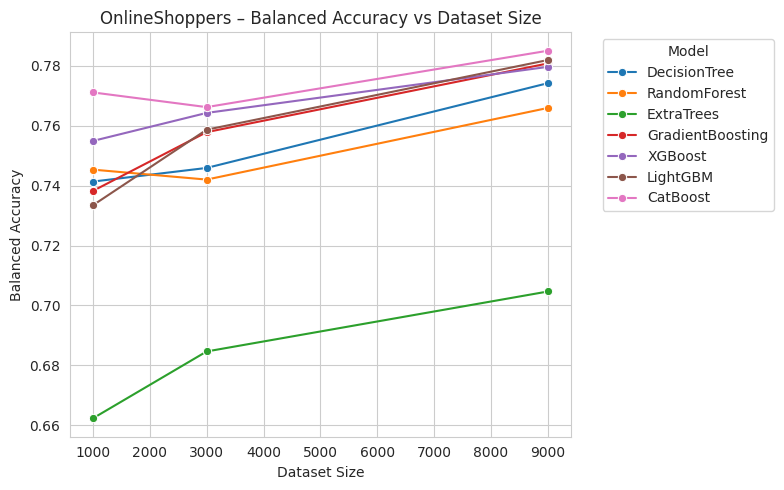

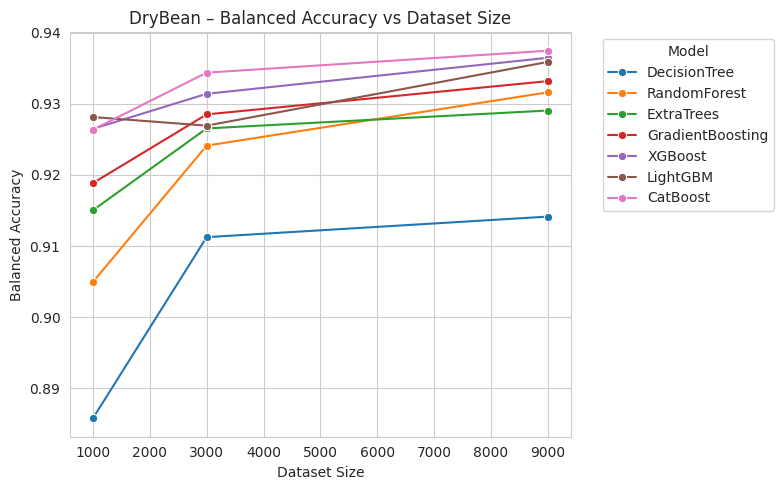

In [12]:
# ==================================================
# Performance vs Dataset Size
# ==================================================

import seaborn as sns
sns.set_style("whitegrid")

for dataset in results_df["dataset"].unique():

    dataset_df = results_df[results_df["dataset"] == dataset]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=dataset_df,
        x="size",
        y="balanced_accuracy",
        hue="model",
        marker="o"
    )

    plt.title(f"{dataset} – Balanced Accuracy vs Dataset Size")
    plt.xlabel("Dataset Size")
    plt.ylabel("Balanced Accuracy")
    plt.legend(title="Model", bbox_to_anchor=(1.05,1))
    plt.tight_layout()

    plt.show()

In [13]:
# ==================================================
# Average Algorithm Ranking
# ==================================================

print("\n==============================")
print("AVERAGE ALGORITHM RANKING")
print("==============================")

for dataset in results_df["dataset"].unique():

    dataset_df = results_df[results_df["dataset"] == dataset].copy()

    dataset_df["rank"] = (
        dataset_df.groupby("size")["balanced_accuracy"]
        .rank(ascending=False, method="min")
    )

    avg_rank = (
        dataset_df.groupby("model")["rank"]
        .mean()
        .sort_values()
    )

    print(f"\nDataset: {dataset}")

    display(
        avg_rank
        .to_frame("Average Rank")
        .round(2)
    )


AVERAGE ALGORITHM RANKING

Dataset: OnlineShoppers


Loading ITables v2.7.1 from the internet... (need help?)



Dataset: DryBean


Loading ITables v2.7.1 from the internet... (need help?)



PERFORMANCE CHANGE HEATMAPS

Dataset: OnlineShoppers


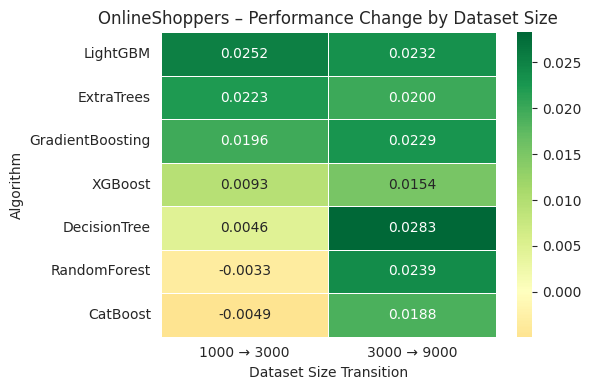


Dataset: DryBean


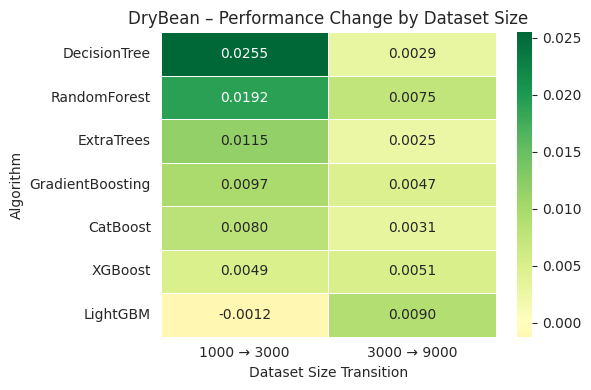

In [14]:
# ==================================================
# Performance Change Heatmaps
# ==================================================

print("\n==============================")
print("PERFORMANCE CHANGE HEATMAPS")
print("==============================")

import seaborn as sns
import matplotlib.pyplot as plt

for dataset in results_df["dataset"].unique():

    print(f"\nDataset: {dataset}")

    # Create pivot table
    pivot = (
        results_df[results_df["dataset"] == dataset]
        .pivot(index="model", columns="size", values="balanced_accuracy")
    )

    # Compute performance changes
    change_df = pd.DataFrame({
        "1000 → 3000": pivot[3000] - pivot[1000],
        "3000 → 9000": pivot[9000] - pivot[3000]
    })

    # Sort models by largest improvement
    change_df = change_df.sort_values("1000 → 3000", ascending=False)

    # Plot heatmap
    plt.figure(figsize=(6,4))

    sns.heatmap(
        change_df,
        annot=True,
        fmt=".4f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5
    )

    plt.title(f"{dataset} – Performance Change by Dataset Size")
    plt.ylabel("Algorithm")
    plt.xlabel("Dataset Size Transition")

    plt.tight_layout()
    plt.show()

# 12) Class Imbalance Manipulation
This section investigates how classification algorithms behave when class distributions become increasingly imbalanced.

The severity of imbalance is measured using the **Imbalance Ratio (IR)**:

IR = largest class size / smallest class size

Three imbalance levels are examined:

• IR = 1  → balanced baseline condition  
• IR = 4  → moderate imbalance  
• IR = 9  → severe imbalance  

To ensure that performance differences arise **only from class distribution changes**, the dataset size is kept constant in all imbalance experiments:

N = 3600 observations

Two different procedures are used depending on the dataset type:

---

## Binary Dataset (Online Shoppers)

For the binary dataset, class counts are directly controlled according to the imbalance ratio.  
If IR = R, then:

Majority / Minority = R

The dataset size is fixed to 3600, therefore class counts are computed automatically using:

Minority = N / (R + 1)  
Majority = N − Minority

This ensures that the imbalance ratio is approximately equal to the target value while maintaining the constant dataset size.

---

## Multi-class Dataset (Dry Bean)

For the multi-class dataset, imbalance is generated while **preserving the original ranking of classes**.

This means:

• the largest class remains the largest  
• the smallest class remains the smallest  
• intermediate classes remain between them

The class frequencies are mapped linearly between the smallest and largest class sizes while maintaining their original order.  
This approach produces realistic class distributions while achieving the desired imbalance ratio.

---

Each imbalance condition represents a **separate dataset version** that will be used in later model evaluation experiments.

In [15]:
# ==================================================
# PART 1 — Class Imbalance Experiment Setup
# ==================================================

import os
import shutil
import numpy as np
import pandas as pd

# --------------------------------------------------
# Fixed dataset size and imbalance ratios
# --------------------------------------------------
# All imbalance experiments use the same dataset size
# so that performance differences are caused ONLY by
# class distribution changes.

N_IMBALANCE = 3600

# Imbalance ratios tested
imbalance_levels = [1, 4, 9]


# --------------------------------------------------
# Define dataset storage location
# --------------------------------------------------
# Generated datasets are stored in the repository
# so they do not need to be regenerated every time.

IMBALANCE_DATASETS_PATH = os.path.join(
    BASE_PATH,
    "datasets",
    "generated_datasets",
    "imbalance_experiments"
)

# Ensure the directory exists
os.makedirs(IMBALANCE_DATASETS_PATH, exist_ok=True)


# --------------------------------------------------
# Define dataset file paths
# --------------------------------------------------
# Each imbalance level corresponds to a CSV dataset.

shoppers_imbalance_files = {
    IR: os.path.join(
        IMBALANCE_DATASETS_PATH,
        f"shoppers_IR_{IR}.csv"
    )
    for IR in imbalance_levels
}

beans_imbalance_files = {
    IR: os.path.join(
        IMBALANCE_DATASETS_PATH,
        f"beans_IR_{IR}.csv"
    )
    for IR in imbalance_levels
}


# --------------------------------------------------
# Detect binary class labels automatically
# --------------------------------------------------
# This avoids hardcoding class labels.

binary_class_counts = pd.Series(y_shoppers).value_counts()

majority_label = binary_class_counts.idxmax()
minority_label = binary_class_counts.idxmin()

print("Detected Online Shoppers class distribution:")
print(binary_class_counts)


# --------------------------------------------------
# Function: compute class counts from imbalance ratio
# --------------------------------------------------

def generate_binary_counts(N, R):
    """
    Computes class counts for a binary dataset given
    a target imbalance ratio.

    N : total dataset size
    R : imbalance ratio (majority / minority)
    """

    minority = int(round(N / (R + 1)))
    majority = N - minority

    return majority, minority


# --------------------------------------------------
# Function: stratified sampling by class counts
# --------------------------------------------------

def sample_by_class_counts(X, y, class_counts, seed=SEED):
    """
    Creates a dataset subset with specific class counts.

    Parameters
    ----------
    X : feature matrix
    y : target vector
    class_counts : dictionary {class_label : count}
    seed : random seed

    Returns
    -------
    X_subset, y_subset
    """

    X = pd.DataFrame(X)
    y = pd.Series(y)

    rng = np.random.RandomState(seed)

    sampled_indices = []

    for cls, count in class_counts.items():

        class_indices = y[y == cls].index

        chosen = rng.choice(
            class_indices,
            size=count,
            replace=False
        )

        sampled_indices.extend(chosen)

    sampled_indices = np.array(sampled_indices)

    X_subset = X.loc[sampled_indices].reset_index(drop=True)
    y_subset = y.loc[sampled_indices].reset_index(drop=True)

    return X_subset, y_subset


# --------------------------------------------------
# Detect Dry Bean class distribution
# --------------------------------------------------
# This will be used for multi-class imbalance generation.

bean_class_counts = (
    pd.Series(y_beans)
    .value_counts()
    .sort_values(ascending=False)
)

bean_labels = bean_class_counts.index.tolist()
bean_original_counts = bean_class_counts.values.tolist()

print("\nDetected Dry Bean encoded class distribution:")
print(bean_class_counts)


# --------------------------------------------------
# Function: generate rank-preserving multi-class counts
# --------------------------------------------------

def linear_rank_preserving_counts(class_labels, original_counts, N, R):
    """
    Generates multi-class imbalance distributions
    while preserving the original class ranking.

    The largest class remains largest and the smallest
    remains smallest.
    """

    original_counts = np.array(original_counts, dtype=float)

    orig_max = original_counts.max()
    orig_min = original_counts.min()

    # Normalize class sizes
    if orig_max == orig_min:
        base = np.ones(len(original_counts))
    else:
        t = (original_counts - orig_min) / (orig_max - orig_min)
        base = 1 + (R - 1) * t

    # Scale to match dataset size
    m = N / base.sum()
    raw = m * base

    counts = np.floor(raw).astype(int)

    # Adjust rounding remainder
    remainder = N - counts.sum()

    frac = raw - np.floor(raw)
    order = np.argsort(-frac)

    for i in range(remainder):
        counts[order[i]] += 1

    return dict(zip(class_labels, counts))

Detected Online Shoppers class distribution:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Detected Dry Bean encoded class distribution:
Class
3    3546
6    2636
5    2027
4    1928
2    1630
0    1322
1     522
Name: count, dtype: int64


In [16]:
# ==================================================
# PART 2 — Load or Generate Imbalance Datasets
# ==================================================

# --------------------------------------------------
# Check whether datasets already exist
# --------------------------------------------------

imbalance_files_exist = all(
    os.path.exists(f)
    for f in list(shoppers_imbalance_files.values())
    + list(beans_imbalance_files.values())
)


# --------------------------------------------------
# Load existing imbalance datasets
# --------------------------------------------------

if imbalance_files_exist:

    print("\nClass imbalance datasets found locally. Loading...")

    shoppers_imbalance_subsets = {}
    beans_imbalance_subsets = {}

    for IR in sorted(imbalance_levels):

        # Load Online Shoppers dataset
        df = pd.read_csv(shoppers_imbalance_files[IR])

        shoppers_imbalance_subsets[IR] = (
            df.drop(columns=["Revenue"]),
            df["Revenue"]
        )

        # Load Dry Bean dataset
        df = pd.read_csv(beans_imbalance_files[IR])

        beans_imbalance_subsets[IR] = (
            df.drop(columns=["Class"]),
            df["Class"]
        )


# --------------------------------------------------
# Generate datasets if they do not exist
# --------------------------------------------------

else:

    print("\nClass imbalance datasets not found. Generating them...")

    shoppers_imbalance_subsets = {}
    beans_imbalance_subsets = {}

    # --------------------------------------------------
    # Generate Online Shoppers imbalance datasets
    # --------------------------------------------------

    for IR in sorted(imbalance_levels):

        majority, minority = generate_binary_counts(N_IMBALANCE, IR)

        class_counts = {
            majority_label: majority,
            minority_label: minority
        }

        X_sub, y_sub = sample_by_class_counts(
            X_shoppers,
            y_shoppers,
            class_counts,
            seed=SEED
        )

        shoppers_imbalance_subsets[IR] = (X_sub, y_sub)

        print(f"\nOnline Shoppers IR = {IR}")
        print(class_counts)


    # --------------------------------------------------
    # Generate Dry Bean imbalance datasets
    # --------------------------------------------------

    for IR in sorted(imbalance_levels):

        class_counts = linear_rank_preserving_counts(
            bean_labels,
            bean_original_counts,
            N_IMBALANCE,
            IR
        )

        X_sub, y_sub = sample_by_class_counts(
            X_beans,
            y_beans,
            class_counts,
            seed=SEED
        )

        beans_imbalance_subsets[IR] = (X_sub, y_sub)

        print(f"\nDry Bean IR = {IR}")
        print(class_counts)


    # --------------------------------------------------
    # Save generated datasets
    # --------------------------------------------------

    for IR in sorted(imbalance_levels):

        # Save Online Shoppers dataset
        Xs, ys = shoppers_imbalance_subsets[IR]
        df = pd.concat([Xs, ys], axis=1)
        df.to_csv(shoppers_imbalance_files[IR], index=False)

        # Save Dry Bean dataset
        Xb, yb = beans_imbalance_subsets[IR]
        df = pd.concat([Xb, yb], axis=1)
        df.to_csv(beans_imbalance_files[IR], index=False)

    print("\nClass imbalance datasets generated and saved.")


    # --------------------------------------------------
    # Create ZIP archive for easy download
    # --------------------------------------------------

    zip_path = os.path.join(BASE_PATH, "imbalance_datasets")

    shutil.make_archive(
        zip_path,
        "zip",
        IMBALANCE_DATASETS_PATH
    )

    print("\nZIP file created:", zip_path + ".zip")

    try:

        from google.colab import files
        files.download(zip_path + ".zip")

        print("\nIMPORTANT:")
        print("Upload the extracted CSV files to the GitHub folder if not exist:")
        print("datasets/generated_datasets/imbalance_experiments/")

    except:

        print("Automatic download skipped (not running in Colab).")


Class imbalance datasets found locally. Loading...



# 13) Class Imbalance Experiment - Model Evaluation

This section evaluates the performance of the seven machine learning algorithms under different class imbalance conditions.

Each imbalance level generated in Section 13 is treated as a separate dataset version.

The same evaluation procedure described in Section 2.5 is applied:

• Stratified 5-fold cross-validation  
• Balanced Accuracy as the primary evaluation metric  
• Precision, Recall, and F1-score as complementary metrics  
• Measurement of model training time

Stratified cross-validation ensures that the class distribution within each fold reflects the distribution of the dataset.

For the multi-class dataset (Dry Bean), macro-averaged Precision, Recall, and F1-score are used to ensure that each class contributes equally to the evaluation.

The tuned hyperparameters obtained earlier are reused so that algorithm comparisons remain fair and consistent across all dataset versions.

In [17]:
# ==================================================
# Class Imbalance Experiment – Model Evaluation
# ==================================================

from sklearn.model_selection import cross_validate

results_imbalance = []

# --------------------------------------------------
# Function to evaluate imbalance subsets
# --------------------------------------------------

def evaluate_imbalance_subsets(subsets, dataset_name, best_params, preprocessor, is_multiclass):

    for IR in sorted(subsets.keys()):

        X_subset, y_subset = subsets[IR]

        for model_name, model in models.items():

            # ----------------------------------------
            # Apply tuned hyperparameters
            # ----------------------------------------

            if model_name in best_params:

                tuned_params = {
                    k.replace("model__", ""): v
                    for k, v in best_params[model_name]["best_params"].items()
                }

                model.set_params(**tuned_params)

            pipeline = Pipeline([
                ("preprocessing", preprocessor),
                ("model", model)
            ])

            # ----------------------------------------
            # Define metrics depending on dataset type
            # ----------------------------------------

            if is_multiclass:

                scoring = {
                    "balanced_accuracy": "balanced_accuracy",
                    "macro_precision": "precision_macro",
                    "macro_recall": "recall_macro",
                    "macro_f1": "f1_macro"
                }

            else:

                scoring = {
                    "balanced_accuracy": "balanced_accuracy",
                    "precision": "precision",
                    "recall": "recall",
                    "f1": "f1"
                }

            # ----------------------------------------
            # Cross-validation evaluation
            # ----------------------------------------

            cv_results = cross_validate(
                estimator=pipeline,
                X=X_subset,
                y=y_subset,
                cv=cv,
                scoring=scoring,
                n_jobs=1,
                return_train_score=False
            )

            # ----------------------------------------
            # Store results
            # ----------------------------------------

            result_entry = {
                "dataset": dataset_name,
                "imbalance_ratio": IR,
                "model": model_name,
                "balanced_accuracy": cv_results["test_balanced_accuracy"].mean(),
                "training_time": cv_results["fit_time"].mean()
            }

            if is_multiclass:

                result_entry["macro_precision"] = cv_results["test_macro_precision"].mean()
                result_entry["macro_recall"] = cv_results["test_macro_recall"].mean()
                result_entry["macro_f1"] = cv_results["test_macro_f1"].mean()

            else:

                result_entry["precision"] = cv_results["test_precision"].mean()
                result_entry["recall"] = cv_results["test_recall"].mean()
                result_entry["f1"] = cv_results["test_f1"].mean()

            results_imbalance.append(result_entry)


# --------------------------------------------------
# Run evaluation for both datasets
# --------------------------------------------------

evaluate_imbalance_subsets(
    shoppers_imbalance_subsets,
    "OnlineShoppers",
    best_params_shoppers,
    preprocessor_shoppers,
    is_multiclass=False
)

evaluate_imbalance_subsets(
    beans_imbalance_subsets,
    "DryBean",
    best_params_beans,
    preprocessor_beans,
    is_multiclass=True
)


# --------------------------------------------------
# Convert results to DataFrame
# --------------------------------------------------

results_imbalance_df = pd.DataFrame(results_imbalance)


# --------------------------------------------------
# Save results
# --------------------------------------------------

RESULTS_PATH = os.path.join(BASE_PATH, "results")
os.makedirs(RESULTS_PATH, exist_ok=True)

results_imbalance_df.to_csv(
    os.path.join(RESULTS_PATH, "class_imbalance_results.csv"),
    index=False
)

print("Class imbalance experiment completed.")

Class imbalance experiment completed.


In [18]:
# ==================================================
# Interactive Results Tables (Sortable)
# ==================================================

from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

print("\n==============================")
print("CLASS IMBALANCE EXPERIMENT RESULTS")
print("==============================")

for dataset in results_imbalance_df["dataset"].unique():

    print(f"\n========== {dataset.upper()} ==========")

    dataset_df = results_imbalance_df[
        results_imbalance_df["dataset"] == dataset
    ]

    # Select correct metrics depending on dataset
    if dataset == "DryBean":

        metric_columns = [
            "macro_precision",
            "macro_recall",
            "macro_f1"
        ]

    else:

        metric_columns = [
            "precision",
            "recall",
            "f1"
        ]

    for IR in sorted(dataset_df["imbalance_ratio"].unique()):

        print(f"\nImbalance Ratio = {IR}")

        subset = dataset_df[
            dataset_df["imbalance_ratio"] == IR
        ]

        columns = ["model","balanced_accuracy"] + metric_columns + ["training_time"]

        table = (
            subset[columns]
            .round(4)
            .reset_index(drop=True)
        )

        show(
            table,
            paging=False,
            searching=False,
            order=[]
        )


CLASS IMBALANCE EXPERIMENT RESULTS

========== ONLINESHOPPERS ==========

Imbalance Ratio = 1


Loading ITables v2.7.1 from the internet... (need help?)



Imbalance Ratio = 4


Loading ITables v2.7.1 from the internet... (need help?)



Imbalance Ratio = 9


...

Loading ITables v2.7.1 from the internet... (need help?)



Imbalance Ratio = 4


Loading ITables v2.7.1 from the internet... (need help?)



Imbalance Ratio = 9


Loading ITables v2.7.1 from the internet... (need help?)


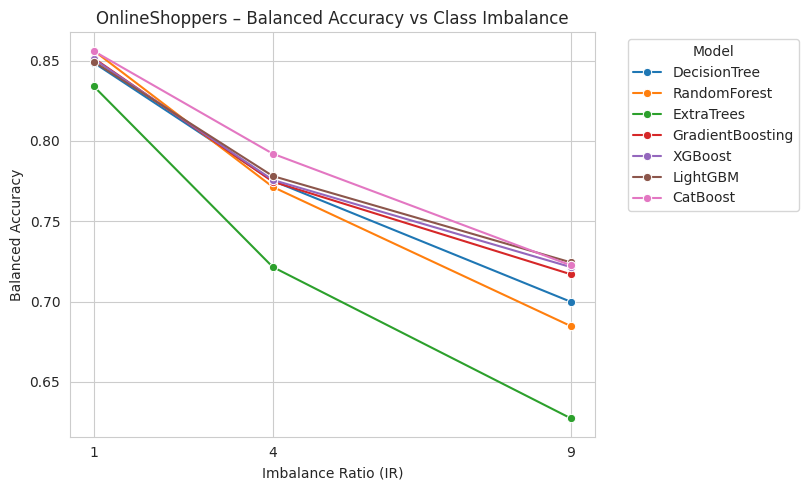

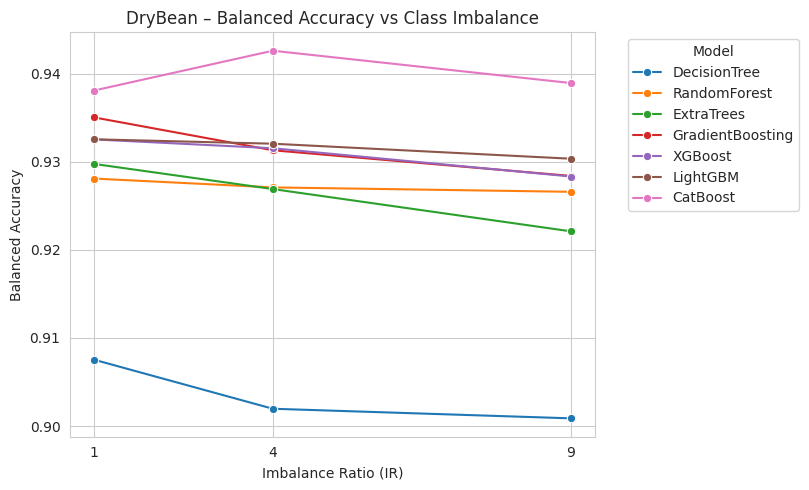

In [39]:
# ==================================================
# Performance vs Class Imbalance
# ==================================================

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

for dataset in results_imbalance_df["dataset"].unique():

    dataset_df = results_imbalance_df[
        results_imbalance_df["dataset"] == dataset
    ]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=dataset_df,
        x="imbalance_ratio",
        y="balanced_accuracy",
        hue="model",
        marker="o"
    )

    plt.title(f"{dataset} – Balanced Accuracy vs Class Imbalance")
    plt.xlabel("Imbalance Ratio (IR)")
    plt.ylabel("Balanced Accuracy")

    plt.xticks([1,4,9])

    # 🔥 MOVE LEGEND FURTHER RIGHT (fix overlap)
    plt.legend(
        title="Model",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    # 🔥 ADD SPACE ON RIGHT
    plt.subplots_adjust(right=0.3)

    plt.tight_layout()
    plt.show()

In [20]:
# ==================================================
# Average Algorithm Ranking
# ==================================================

print("\n==============================")
print("AVERAGE ALGORITHM RANKING")
print("==============================")

for dataset in results_imbalance_df["dataset"].unique():

    dataset_df = results_imbalance_df[
        results_imbalance_df["dataset"] == dataset
    ].copy()

    dataset_df["rank"] = (
        dataset_df
        .groupby("imbalance_ratio")["balanced_accuracy"]
        .rank(ascending=False, method="min")
    )

    avg_rank = (
        dataset_df
        .groupby("model")["rank"]
        .mean()
        .sort_values()
    )

    print(f"\nDataset: {dataset}")

    display(
        avg_rank
        .to_frame("Average Rank")
        .round(2)
    )


AVERAGE ALGORITHM RANKING

Dataset: OnlineShoppers


Loading ITables v2.7.1 from the internet... (need help?)



Dataset: DryBean


Loading ITables v2.7.1 from the internet... (need help?)



PERFORMANCE CHANGE HEATMAPS

Dataset: OnlineShoppers


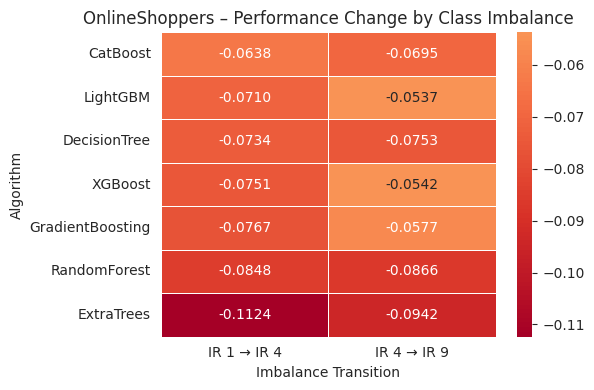


Dataset: DryBean


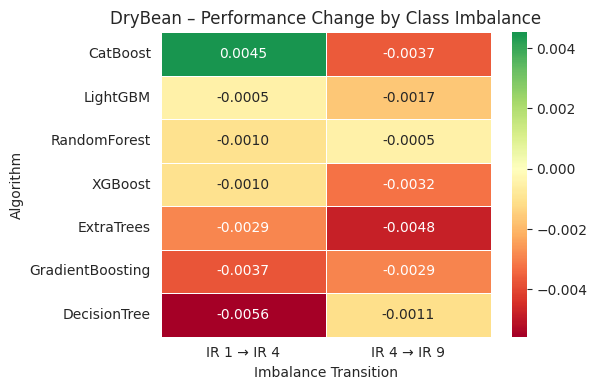

In [21]:
# ==================================================
# Performance Change Heatmaps
# ==================================================

print("\n==============================")
print("PERFORMANCE CHANGE HEATMAPS")
print("==============================")

import seaborn as sns
import matplotlib.pyplot as plt

for dataset in results_imbalance_df["dataset"].unique():

    print(f"\nDataset: {dataset}")

    pivot = (
        results_imbalance_df[
            results_imbalance_df["dataset"] == dataset
        ]
        .pivot(index="model",
               columns="imbalance_ratio",
               values="balanced_accuracy")
    )

    change_df = pd.DataFrame({

        "IR 1 → IR 4": pivot[4] - pivot[1],
        "IR 4 → IR 9": pivot[9] - pivot[4]

    })

    change_df = change_df.sort_values(
        "IR 1 → IR 4",
        ascending=False
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        change_df,
        annot=True,
        fmt=".4f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5
    )

    plt.title(f"{dataset} – Performance Change by Class Imbalance")
    plt.ylabel("Algorithm")
    plt.xlabel("Imbalance Transition")

    plt.tight_layout()
    plt.show()

## 14) Statistical Significance Testing

In order to determine whether the observed differences between machine learning algorithms are statistically significant, non-parametric statistical tests are applied.

Following common practice in machine learning research, the **Friedman test** is first used to evaluate whether significant differences exist among the algorithms across multiple experimental conditions.

The Friedman test compares the **average ranks** of the algorithms rather than their raw performance values. This approach is appropriate when multiple algorithms are evaluated across several datasets or experimental settings.

The null hypothesis of the Friedman test is:

H₀: All algorithms perform equally and their ranks are the same.

If the Friedman test rejects the null hypothesis, it indicates that at least one algorithm performs significantly differently from the others.

To identify which specific algorithms differ significantly, the **Nemenyi post-hoc test** is applied. This test compares all pairs of algorithms using their average ranks.

The Nemenyi test uses the **Critical Difference (CD)** value. If the difference between the average ranks of two algorithms exceeds the CD, their performance difference is considered statistically significant.

The results are visualized using a **Critical Difference diagram**, where algorithms that are not significantly different are connected by horizontal lines.

This statistical analysis provides a more rigorous comparison of the algorithms and complements the descriptive results presented in the previous sections.


In [22]:
# ==================================================
# Combine Dataset Size + Imbalance experiments
# ==================================================

size_results = results_df.copy()

size_results["condition"] = (
    size_results["dataset"]
    + "_size_"
    + size_results["size"].astype(str)
)

imbalance_results = results_imbalance_df.copy()

imbalance_results["condition"] = (
    imbalance_results["dataset"]
    + "_IR_"
    + imbalance_results["imbalance_ratio"].astype(str)
)

size_results = size_results[["condition","model","balanced_accuracy"]]
imbalance_results = imbalance_results[["condition","model","balanced_accuracy"]]

all_results = pd.concat([size_results, imbalance_results], ignore_index=True)

print("Total experimental conditions:", all_results["condition"].nunique())


# ==================================================
# Performance Matrix
# ==================================================

pivot = all_results.pivot(
    index="condition",
    columns="model",
    values="balanced_accuracy"
)

print("\nPERFORMANCE MATRIX")
display(pivot.round(4))

# ==================================================
# Friedman Test
# ==================================================

import scipy.stats as stats

stat, p = stats.friedmanchisquare(
    *[pivot[col] for col in pivot.columns]
)

print("\n==============================")
print("FRIEDMAN TEST")
print("==============================")

print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p:.6f}")

if p < 0.05:
    print("Conclusion: Algorithms differ significantly")
else:
    print("Conclusion: No significant differences")


# ==================================================
# Average Ranks
# ==================================================

ranks = pivot.rank(axis=1, ascending=False)

avg_ranks = ranks.mean().sort_values()

rank_table = avg_ranks.reset_index()
rank_table.columns = ["Algorithm","Average Rank"]

print("\nAVERAGE ALGORITHM RANKS")
display(rank_table.round(3))

# ==================================================
# Critical Difference
# ==================================================

import numpy as np

k = len(pivot.columns)
N = len(pivot)

q_alpha = 3.314

CD = q_alpha * np.sqrt(k*(k+1)/(6*N))

print("\nCRITICAL DIFFERENCE")
print("--------------------")

print(f"Algorithms (k): {k}")
print(f"Conditions (N): {N}")
print(f"CD value      : {CD:.4f}")

# ==================================================
# Pairwise CD Comparison (clean table)
# ==================================================

pairs = []

models = avg_ranks.index.tolist()

for i in range(len(models)):
    for j in range(i+1, len(models)):

        m1 = models[i]
        m2 = models[j]

        diff = abs(avg_ranks[m1] - avg_ranks[m2])

        pairs.append({
            "Algorithm A": m1,
            "Algorithm B": m2,
            "Rank Difference": diff,
            "Significant": diff > CD
        })

pairs_df = pd.DataFrame(pairs)

print("\nPAIRWISE COMPARISON")
display(pairs_df.round(3))

# ==================================================
# Only significant differences
# ==================================================

significant = pairs_df[pairs_df["Significant"] == True]

print("\nSIGNIFICANT DIFFERENCES (Nemenyi CD test)")
display(significant.round(3))


Total experimental conditions: 12

PERFORMANCE MATRIX


Loading ITables v2.7.1 from the internet... (need help?)



FRIEDMAN TEST
Statistic : 50.5714
p-value   : 0.000000
Conclusion: Algorithms differ significantly

AVERAGE ALGORITHM RANKS


Loading ITables v2.7.1 from the internet... (need help?)



CRITICAL DIFFERENCE
--------------------
Algorithms (k): 7
Conditions (N): 12
CD value      : 2.9227

PAIRWISE COMPARISON


Loading ITables v2.7.1 from the internet... (need help?)



SIGNIFICANT DIFFERENCES (Nemenyi CD test)


Loading ITables v2.7.1 from the internet... (need help?)


In [23]:
# ==================================================
# Statistical Test — Dataset Size Experiment
# ==================================================

print("\n===================================")
print("STATISTICAL TEST — DATASET SIZE")
print("===================================")

# --------------------------------------------------
# Performance matrix
# --------------------------------------------------

pivot_size = results_df.pivot(
    index=["dataset","size"],
    columns="model",
    values="balanced_accuracy"
)

display(pivot_size.round(4))


# --------------------------------------------------
# Friedman Test
# --------------------------------------------------

import scipy.stats as stats

stat, p = stats.friedmanchisquare(
    *[pivot_size[col] for col in pivot_size.columns]
)

print("\nFRIEDMAN TEST (Dataset Size)")
print("-----------------------------")
print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p:.6f}")

if p < 0.05:
    print("Conclusion: Algorithms differ significantly")
else:
    print("Conclusion: No significant differences")


# --------------------------------------------------
# Average ranks
# --------------------------------------------------

ranks_size = pivot_size.rank(axis=1, ascending=False)
avg_ranks_size = ranks_size.mean().sort_values()

rank_table = avg_ranks_size.reset_index()
rank_table.columns = ["Algorithm","Average Rank"]

print("\nAVERAGE RANKS")
display(rank_table.round(3))


# --------------------------------------------------
# Critical Difference
# --------------------------------------------------

import numpy as np

k = len(pivot_size.columns)
N = len(pivot_size)

q_alpha = 3.314

CD = q_alpha * np.sqrt(k*(k+1)/(6*N))

print("\nCRITICAL DIFFERENCE")
print("--------------------")
print(f"Algorithms (k): {k}")
print(f"Conditions (N): {N}")
print(f"CD value      : {CD:.4f}")


# --------------------------------------------------
# Pairwise comparison
# --------------------------------------------------

pairs = []

models = avg_ranks_size.index.tolist()

for i in range(len(models)):
    for j in range(i+1, len(models)):

        m1 = models[i]
        m2 = models[j]

        diff = abs(avg_ranks_size[m1] - avg_ranks_size[m2])

        pairs.append({
            "Algorithm A": m1,
            "Algorithm B": m2,
            "Rank Difference": diff,
            "Significant": diff > CD
        })

pairs_df = pd.DataFrame(pairs)

print("\nPAIRWISE COMPARISON")
display(pairs_df.round(3))



STATISTICAL TEST — DATASET SIZE


Loading ITables v2.7.1 from the internet... (need help?)



FRIEDMAN TEST (Dataset Size)
-----------------------------
Statistic : 26.2857
p-value   : 0.000197
Conclusion: Algorithms differ significantly

AVERAGE RANKS


Loading ITables v2.7.1 from the internet... (need help?)



CRITICAL DIFFERENCE
--------------------
Algorithms (k): 7
Conditions (N): 6
CD value      : 4.1333

PAIRWISE COMPARISON


Loading ITables v2.7.1 from the internet... (need help?)


In [24]:
# ==================================================
# Statistical Test — Class Imbalance Experiment
# ==================================================

print("\n===================================")
print("STATISTICAL TEST — CLASS IMBALANCE")
print("===================================")

# --------------------------------------------------
# Performance matrix
# --------------------------------------------------

pivot_imbalance = results_imbalance_df.pivot(
    index=["dataset","imbalance_ratio"],
    columns="model",
    values="balanced_accuracy"
)

display(pivot_imbalance.round(4))


# --------------------------------------------------
# Friedman Test
# --------------------------------------------------

stat, p = stats.friedmanchisquare(
    *[pivot_imbalance[col] for col in pivot_imbalance.columns]
)

print("\nFRIEDMAN TEST (Class Imbalance)")
print("--------------------------------")
print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p:.6f}")

if p < 0.05:
    print("Conclusion: Algorithms differ significantly")
else:
    print("Conclusion: No significant differences")


# --------------------------------------------------
# Average ranks
# --------------------------------------------------

ranks_imb = pivot_imbalance.rank(axis=1, ascending=False)
avg_ranks_imb = ranks_imb.mean().sort_values()

rank_table = avg_ranks_imb.reset_index()
rank_table.columns = ["Algorithm","Average Rank"]

print("\nAVERAGE RANKS")
display(rank_table.round(3))


# --------------------------------------------------
# Critical Difference
# --------------------------------------------------

k = len(pivot_imbalance.columns)
N = len(pivot_imbalance)

CD = q_alpha * np.sqrt(k*(k+1)/(6*N))

print("\nCRITICAL DIFFERENCE")
print("--------------------")
print(f"Algorithms (k): {k}")
print(f"Conditions (N): {N}")
print(f"CD value      : {CD:.4f}")


# --------------------------------------------------
# Pairwise comparison
# --------------------------------------------------

pairs = []

models = avg_ranks_imb.index.tolist()

for i in range(len(models)):
    for j in range(i+1, len(models)):

        m1 = models[i]
        m2 = models[j]

        diff = abs(avg_ranks_imb[m1] - avg_ranks_imb[m2])

        pairs.append({
            "Algorithm A": m1,
            "Algorithm B": m2,
            "Rank Difference": diff,
            "Significant": diff > CD
        })

pairs_df = pd.DataFrame(pairs)

print("\nPAIRWISE COMPARISON")
display(pairs_df.round(3))



STATISTICAL TEST — CLASS IMBALANCE


Loading ITables v2.7.1 from the internet... (need help?)



FRIEDMAN TEST (Class Imbalance)
--------------------------------
Statistic : 25.7143
p-value   : 0.000252
Conclusion: Algorithms differ significantly

AVERAGE RANKS


Loading ITables v2.7.1 from the internet... (need help?)



CRITICAL DIFFERENCE
--------------------
Algorithms (k): 7
Conditions (N): 6
CD value      : 4.1333

PAIRWISE COMPARISON


Loading ITables v2.7.1 from the internet... (need help?)
